# 1-1

## 1-1-1

In [1]:
# Install gdown for downloading shared Google Drive folders
!pip install gdown

In [2]:


# --- Configuration ---
# Folder ID from your Google Drive link: 1eR-MM1yzrA86N7lAN7Pr3aPdXj0qnd5_
FOLDER_ID = '1eR-MM1yzrA86N7lAN7Pr3aPdXj0qnd5_'
# The data will be downloaded into this folder
DATA_DIR = './IBSR_Data'

# 1. Download the data from the shared folder
print("Starting data download...")
# The contents will be downloaded into a folder named by the ID,
# then we rename/move it for consistency.
!gdown --folder {FOLDER_ID} --output {DATA_DIR}
print(f"Download complete. Data is saved in the directory: {DATA_DIR}")

# 2. Extract the ZIP file (the downloaded content is likely a zip or a folder)
# Assuming the file/folder name inside DATA_DIR is 'IBSR_nifti_stripped.zip' or similar
# If the downloaded folder already contains the NIfTI files directly, skip this.
# If it's a ZIP, you might need to find its name and unzip it:
import zipfile
import os

zip_path = os.path.join(DATA_DIR, 'IBSR_nifti_stripped.zip')
if os.path.exists(zip_path):
    print(f"Found ZIP file at {zip_path}. Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete.")

# Set the final path to the folder containing IBSR_01, IBSR_02, etc.
# Adjust 'IBSR_nifti_stripped' if the folder name is different after extraction.
FINAL_DATA_PATH = os.path.join(DATA_DIR, 'IBSR_nifti_stripped', 'IBSR_nifti_stripped')
if not os.path.exists(FINAL_DATA_PATH):
    # Fallback/simplification in case extraction resulted in a different structure
    FINAL_DATA_PATH = DATA_DIR

print(f"Final directory path for file scanning: {FINAL_DATA_PATH}")
print("---")

Starting data download...
Retrieving folder contents
Processing file 1Q37u5v3a01I7n_B0iFbFeZoVipvK4ccq IBSR_nifti_stripped.zip
Processing file 1ebbV0obAlUQHIy8zKt0RAygMqzt78Dd9 README.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1Q37u5v3a01I7n_B0iFbFeZoVipvK4ccq
From (redirected): https://drive.google.com/uc?id=1Q37u5v3a01I7n_B0iFbFeZoVipvK4ccq&confirm=t&uuid=665c5f14-1fd1-4dc9-91b9-6c57b2cd7656
To: /kaggle/working/IBSR_Data/IBSR_nifti_stripped.zip
100%|██████████████████████████████████████| 77.6M/77.6M [00:01<00:00, 77.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ebbV0obAlUQHIy8zKt0RAygMqzt78Dd9
To: /kaggle/working/IBSR_Data/README.txt
100%|██████████████████████████████████████| 20.9k/20.9k [00:00<00:00, 50.1MB/s]
Download completed
Download complete. Data is saved in the directory: ./IBSR_Data
Found ZIP file at ./IBSR_Data/IBSR_nifti_stripped

In [3]:
import numpy as np
import nibabel as nib
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
import glob

# --- Corrected File Path Loading Function (Handles Subfolders) ---
def load_file_paths(data_dir):
    """
    Scans the data directory and its subfolders for volume and segmentation files.
    """
    if not os.path.exists(data_dir):
        print(f"Error: Data directory not found at {data_dir}.")
        return [], []

    # Use glob with ** (recursive search) to find files in subdirectories (IBSR_01, etc.)
    # Note: Requires os.path.join(..., '**', ...)
    vol_pattern = os.path.join(data_dir, '**', '*_ana_strip.nii.gz')
    volume_files = sorted(glob.glob(vol_pattern, recursive=True))

    segmentation_files = []
    final_volume_files = []

    # Pair the found volumes with their expected masks
    for vol_path in volume_files:
        # Get the filename (e.g., 'IBSR_01_ana_strip.nii.gz')
        vol_filename = os.path.basename(vol_path)
        # Construct the expected mask filename (e.g., 'IBSR_01_segTRI_fill_ana.nii.gz')
        base_name = vol_filename.replace('_ana_strip.nii.gz', '')
        seg_filename = base_name + '_segTRI_fill_ana.nii.gz'

        # The mask must be in the same directory as the volume file
        seg_path = os.path.join(os.path.dirname(vol_path), seg_filename)

        if os.path.exists(seg_path):
            final_volume_files.append(vol_path)
            segmentation_files.append(seg_path)
        else:
            warnings.warn(f"Warning: Segmentation mask not found for {vol_path}. Skipping.")

    print(f"Found {len(segmentation_files)} patient file pairs to load.")
    return final_volume_files, segmentation_files


# --- Helper Functions (From previous step) ---

def get_slice_data(volume_data, seg_data, axis, slice_idx):
    """ Extracts, squeezes, and rotates a 2D slice from the 3D data. """
    if axis == 0: vol_slice, seg_slice = volume_data[slice_idx, :, :], seg_data[slice_idx, :, :]
    elif axis == 1: vol_slice, seg_slice = volume_data[:, slice_idx, :], seg_data[:, slice_idx, :]
    else: vol_slice, seg_slice = volume_data[:, :, slice_idx], seg_data[:, :, slice_idx]

    vol_slice, seg_slice = np.squeeze(vol_slice), np.squeeze(seg_slice)
    vol_slice_rotated, seg_slice_rotated = np.rot90(vol_slice, k=1), np.rot90(seg_slice, k=1)
    return vol_slice_rotated, seg_slice_rotated

def pad_slice(vol_slice, seg_slice, target_dims=(256, 256)):
    """ Pads the 2D slice to the target dimensions (256x256). """
    h, w = vol_slice.shape
    th, tw = target_dims

    pad_h_top, pad_h_bottom = (th - h) // 2, th - h - (th - h) // 2
    pad_w_left, pad_w_right = (tw - w) // 2, tw - w - (tw - w) // 2

    padding = ((max(0, pad_h_top), max(0, pad_h_bottom)),
               (max(0, pad_w_left), max(0, pad_w_right)))

    vol_padded = np.pad(vol_slice, padding, mode='constant', constant_values=0)
    seg_padded = np.pad(seg_slice, padding, mode='constant', constant_values=0)

    return vol_padded[:th, :tw], seg_padded[:th, :tw]


# --- PyTorch Dataset Class ---
class IBSRPatchDataset(Dataset):

    def __init__(self, volume_files, segmentation_files):
        self.patches = []
        self.masks = []
        self.patch_size = 128
        self.target_dims = (256, 256)
        self.slice_start = 10
        self.slice_stride = 3
        self.num_slices_to_extract = 48

        print("Loading and processing dataset...")
        for vol_path, seg_path in zip(volume_files, segmentation_files):
            try:
                vol_data = nib.load(vol_path).get_fdata()
                seg_data = nib.load(seg_path).get_fdata()

                # Process all three axes (x, y, z)
                for axis in range(3):
                    num_slices_in_axis = vol_data.shape[axis]
                    slice_indices = list(range(
                        self.slice_start, num_slices_in_axis, self.slice_stride
                    ))[:self.num_slices_to_extract]

                    for slice_idx in slice_indices:
                        vol_slice, seg_slice = get_slice_data(vol_data, seg_data, axis, slice_idx)
                        vol_padded, seg_padded = pad_slice(vol_slice, seg_slice, self.target_dims)

                        # Extract four 128x128 patches
                        for x in [0, self.patch_size]:
                            for y in [0, self.patch_size]:
                                self.patches.append(vol_padded[x : x + self.patch_size, y : y + self.patch_size])
                                self.masks.append(seg_padded[x : x + self.patch_size, y : y + self.patch_size])
            except Exception as e:
                warnings.warn(f"Warning: Skipping file {vol_path} due to error: {e}")

        print(f"Dataset loaded. Total patches: {len(self.patches)}")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        vol_patch = self.patches[idx].astype(np.float32)
        seg_patch = self.masks[idx].astype(np.int64)

        # NOTE: Apply normalization here if required
        vol_patch_normalized = vol_patch

        # Image: [1, 128, 128] (Channel first)
        vol_tensor = torch.tensor(vol_patch_normalized, dtype=torch.float32).unsqueeze(0)
        # Mask: [128, 128] (Long type for segmentation targets)
        mask_tensor = torch.tensor(seg_patch, dtype=torch.long)

        return vol_tensor, mask_tensor

In [4]:
import nibabel as nib

def print_initial_sizes(volume_files, segmentation_files):
    print("=== Initial Dimensions of Each Patient ===\n")

    for vol_path, seg_path in zip(volume_files, segmentation_files):
        vol = nib.load(vol_path).get_fdata()
        seg = nib.load(seg_path).get_fdata()

        print(f"Patient: {vol_path.split('/')[-1][:7]}")
        print(f"  Volume shape      : {vol.shape}")
        print(f"  Segmentation shape: {seg.shape}")
        print("-------------------------------------------")


In [5]:
data_dir = "./IBSR_Data"

vols, masks = load_file_paths(data_dir)
print_initial_sizes(vols, masks)




Found 18 patient file pairs to load.
=== Initial Dimensions of Each Patient ===

Patient: IBSR_01
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_02
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_03
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_04
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_05
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_06
  Volume shape      : (256, 128, 256, 1)
  Segmentation shape: (256, 128, 256, 1)
-------------------------------------------
Patient: IBSR_07
  Volume shape      : (256, 128, 256, 1)
  S

## 1-1-2

In [6]:
from torch.utils.data import DataLoader, ConcatDataset

def split_dataset_volumes(vols, masks, batch_size=1):
    """
    Split dataset at the volume level instead of patch level.
    vols, masks: lists of file paths
    """
    num_vols = len(vols)
    train_size = 12
    val_size = 6

    # Shuffle indices
    indices = torch.randperm(num_vols)
    train_idx = indices[:train_size]
    val_idx = indices[train_size:]

    # Split volumes
    train_vols = [vols[i] for i in train_idx]
    train_masks = [masks[i] for i in train_idx]
    val_vols = [vols[i] for i in val_idx]
    val_masks = [masks[i] for i in val_idx]

    # Create dataset per split
    train_dataset = IBSRPatchDataset(train_vols, train_masks)
    val_dataset = IBSRPatchDataset(val_vols, val_masks)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"Train volumes: {len(train_vols)}, patches: {len(train_dataset)}")
    print(f"Validation volumes: {len(val_vols)}, patches: {len(val_dataset)}")

    return train_loader, val_loader


In [7]:
# Suppose vols and masks are lists of file paths
train_loader, val_loader = split_dataset_volumes(vols, masks, batch_size=1)


Loading and processing dataset...
Dataset loaded. Total patches: 6528
Loading and processing dataset...
Dataset loaded. Total patches: 3264
Train volumes: 12, patches: 6528
Validation volumes: 6, patches: 3264


In [8]:
import torch
from collections import defaultdict
from typing import Dict, Tuple

def report_class_balances(train_loader: torch.utils.data.DataLoader, n_classes: int) -> Dict[int, float]:
    """
    Calculates the pixel-wise class frequency in the entire training dataset.
    
    Args:
        train_loader: DataLoader containing the training data (images, masks).
        n_classes: The total number of segmentation classes.
        
    Returns:
        A dictionary mapping class index to its pixel percentage (0-100).
    """
    pixel_counts = defaultdict(int)
    total_pixels = 0
    
    # Disable gradient tracking as we are only counting pixels
    with torch.no_grad():
        for images, masks in train_loader:
            # Masks is typically [B, H, W] containing integer class labels
            
            # Count total pixels
            total_pixels += masks.numel()
            
            # Count pixels for each class
            for cls in range(n_classes):
                # Count the number of pixels equal to the current class index (cls)
                pixel_counts[cls] += (masks == cls).sum().item()

    # Calculate percentages
    class_balances = {
        cls: (count / total_pixels) * 100
        for cls, count in pixel_counts.items()
    }
    
    # Ensure keys are sorted for clean output
    sorted_balances = {k: class_balances[k] for k in sorted(class_balances)}
    
    return sorted_balances

# --- Execution using your existing variables ---
# You need to define n_classes based on your dataset (typically 4 for IBSR)
n_classes = 4 

class_balances = report_class_balances(train_loader, n_classes=n_classes)

print("\n--- Training Set Class Balances (Pixel-wise) ---")
for cls, percentage in class_balances.items():
    # Assuming typical brain segmentation labels for context
    label_map = {0: "Background/Non-brain", 1: "CSF", 2: "Gray Matter (GM)", 3: "White Matter (WM)"}
    label = label_map.get(cls, f"Class {cls}")
    print(f"[{cls}] {label}: {percentage:.4f}%")

# The class balances are often used to calculate inverse frequency weights for the loss function.
print("\n--- Class Weights Recommendation ---")
# Calculate weights inversely proportional to the frequency (a common strategy)
total_weight = sum(1.0 / p if p > 0 else 0 for p in class_balances.values())
recommended_weights = {}

for cls, percentage in class_balances.items():
    if percentage > 0:
        # Inverse frequency weight
        weight = 1.0 / percentage
        # Normalize the weights so they sum to n_classes (optional but common practice)
        # weight = weight * n_classes / total_weight 
        recommended_weights[cls] = weight

print(f"Recommended CrossEntropyLoss weights (Inverse Frequency): {recommended_weights}")


--- Training Set Class Balances (Pixel-wise) ---
[0] Background/Non-brain: 90.2269%
[1] CSF: 0.8070%
[2] Gray Matter (GM): 5.8355%
[3] White Matter (WM): 3.1307%

--- Class Weights Recommendation ---
Recommended CrossEntropyLoss weights (Inverse Frequency): {0: 0.011083172211341554, 1: 1.2392002270897178, 2: 0.17136493678284678, 3: 0.31942219256942606}


## 1-1-3


   Patient 11

Sagittal → slice 189/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


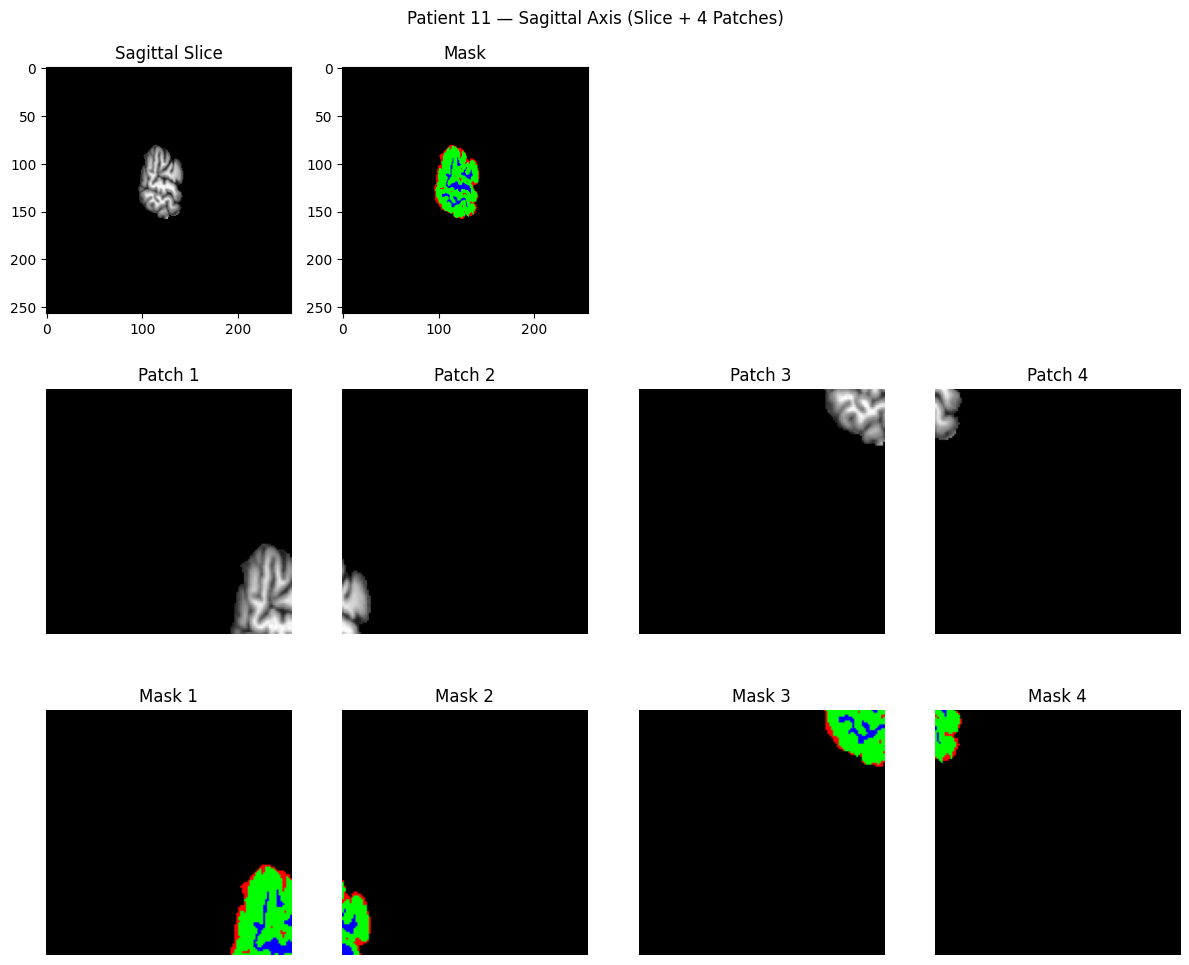

Coronal → slice 70/128 (range 32-96)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


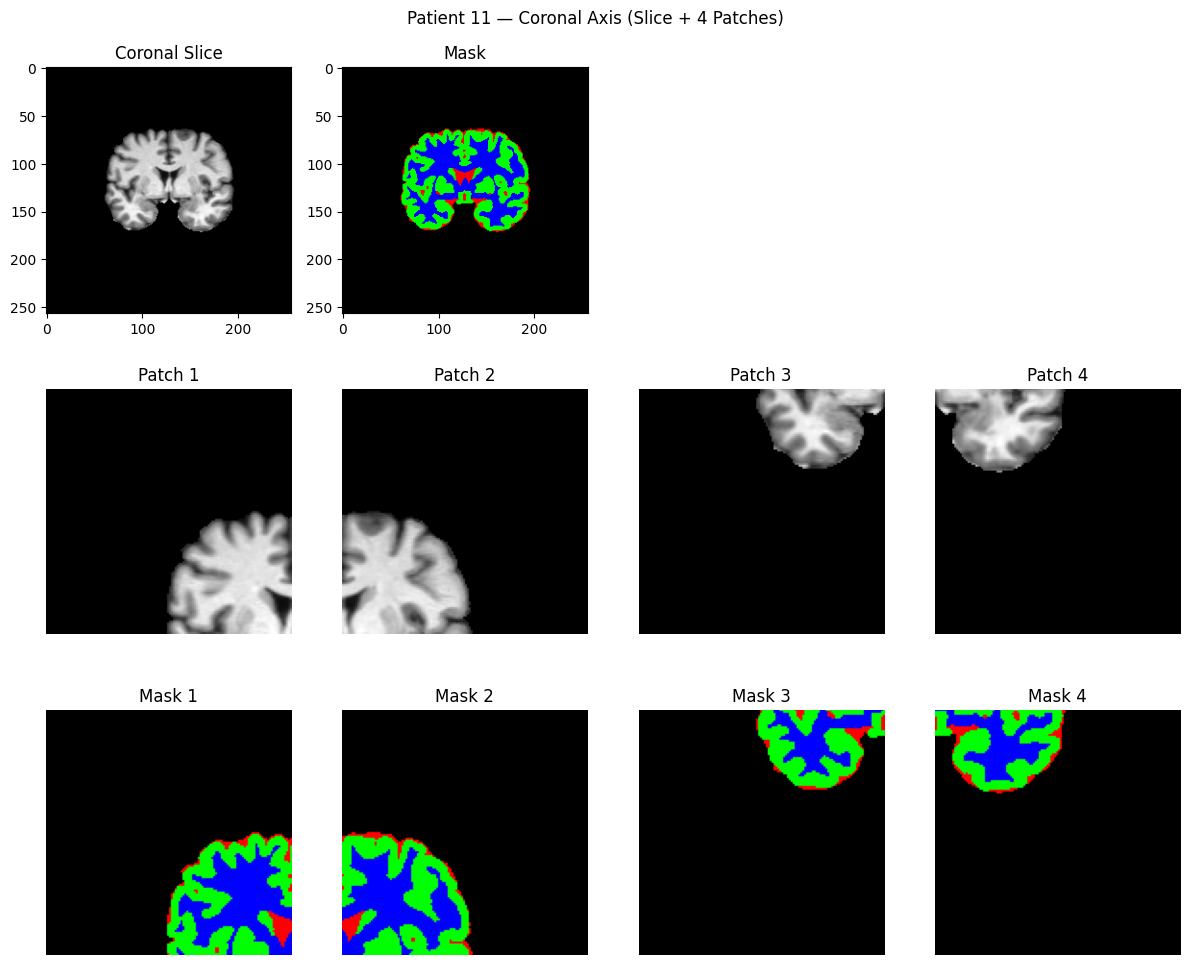

Axial → slice 83/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


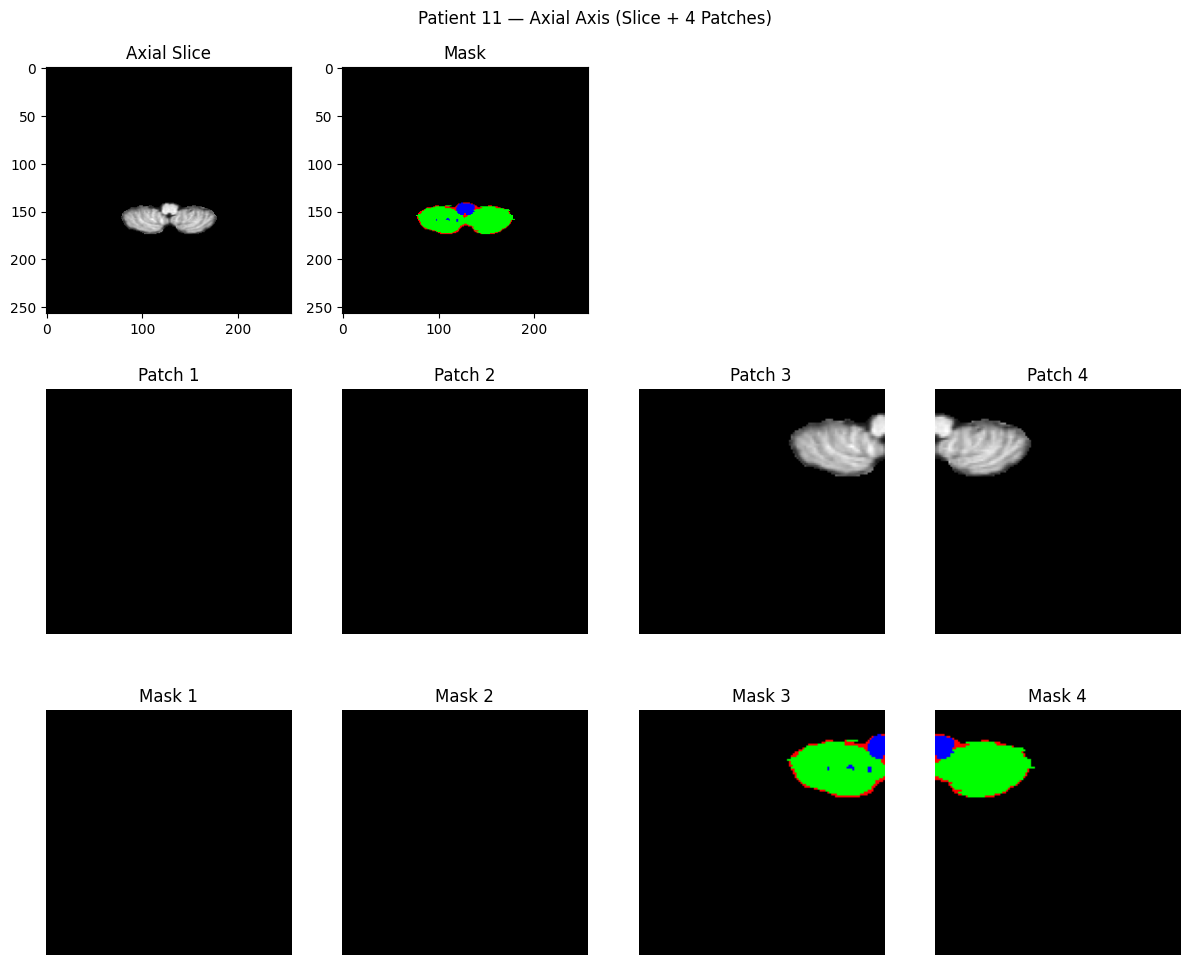


   Patient 8

Sagittal → slice 101/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


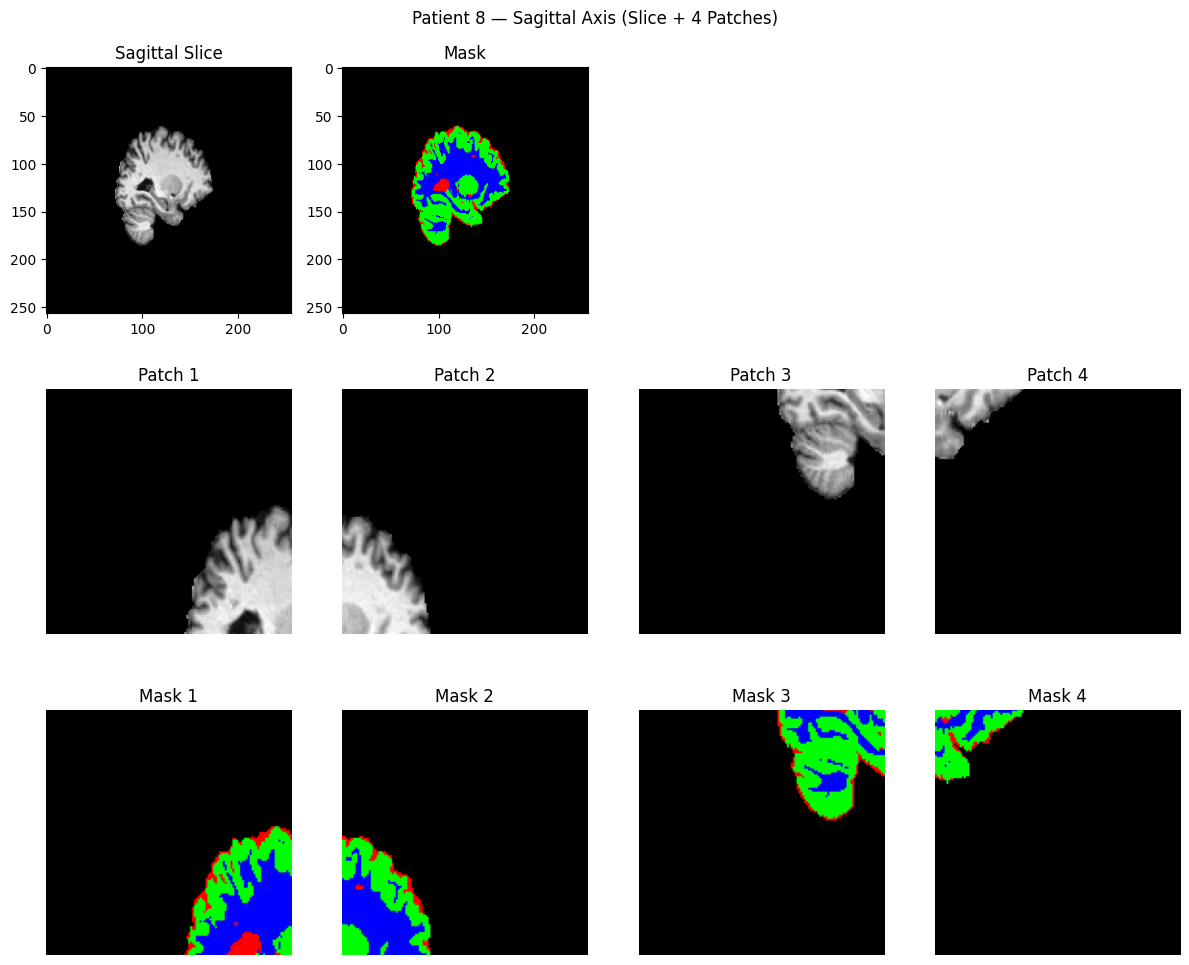

Coronal → slice 63/128 (range 32-96)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


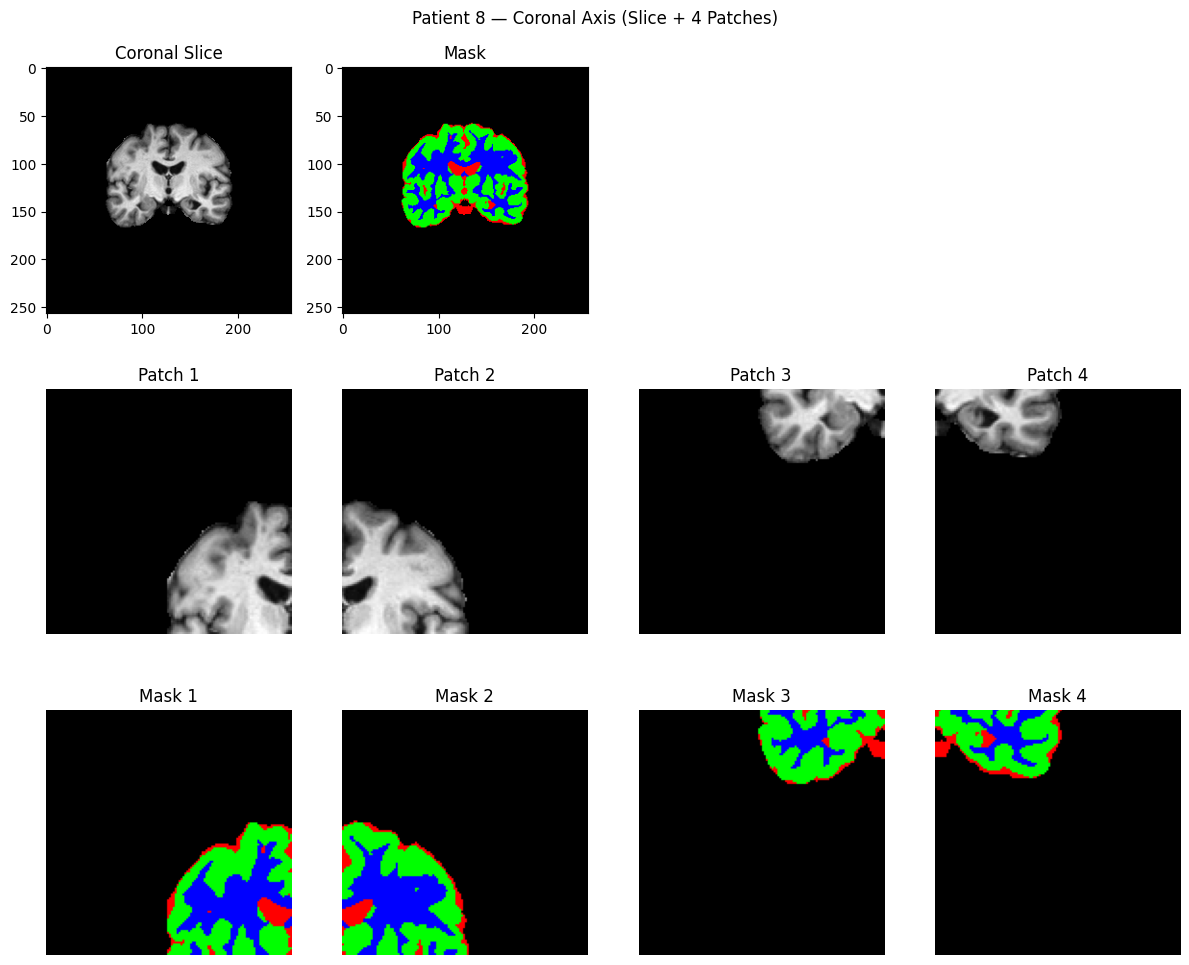

Axial → slice 70/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


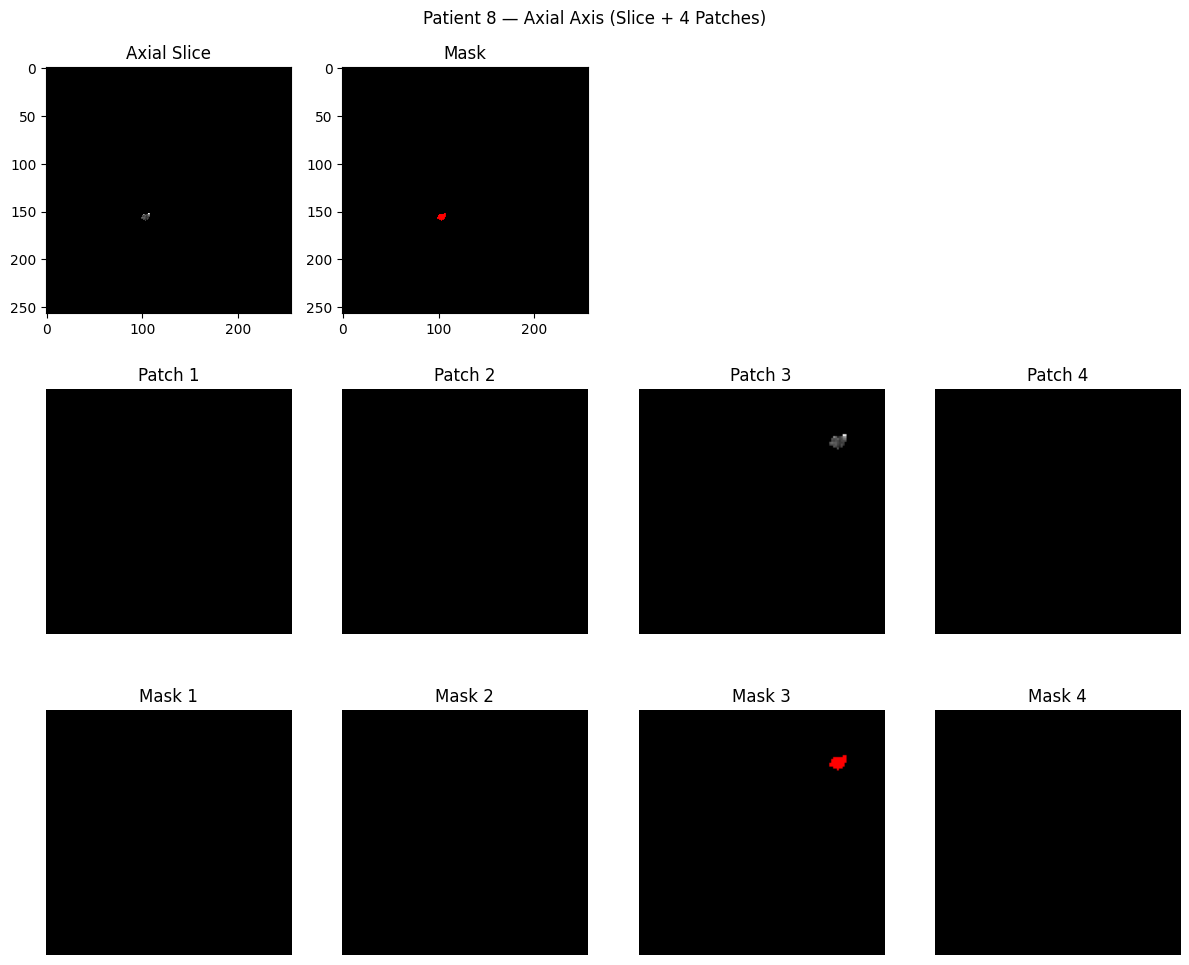


   Patient 2

Sagittal → slice 81/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


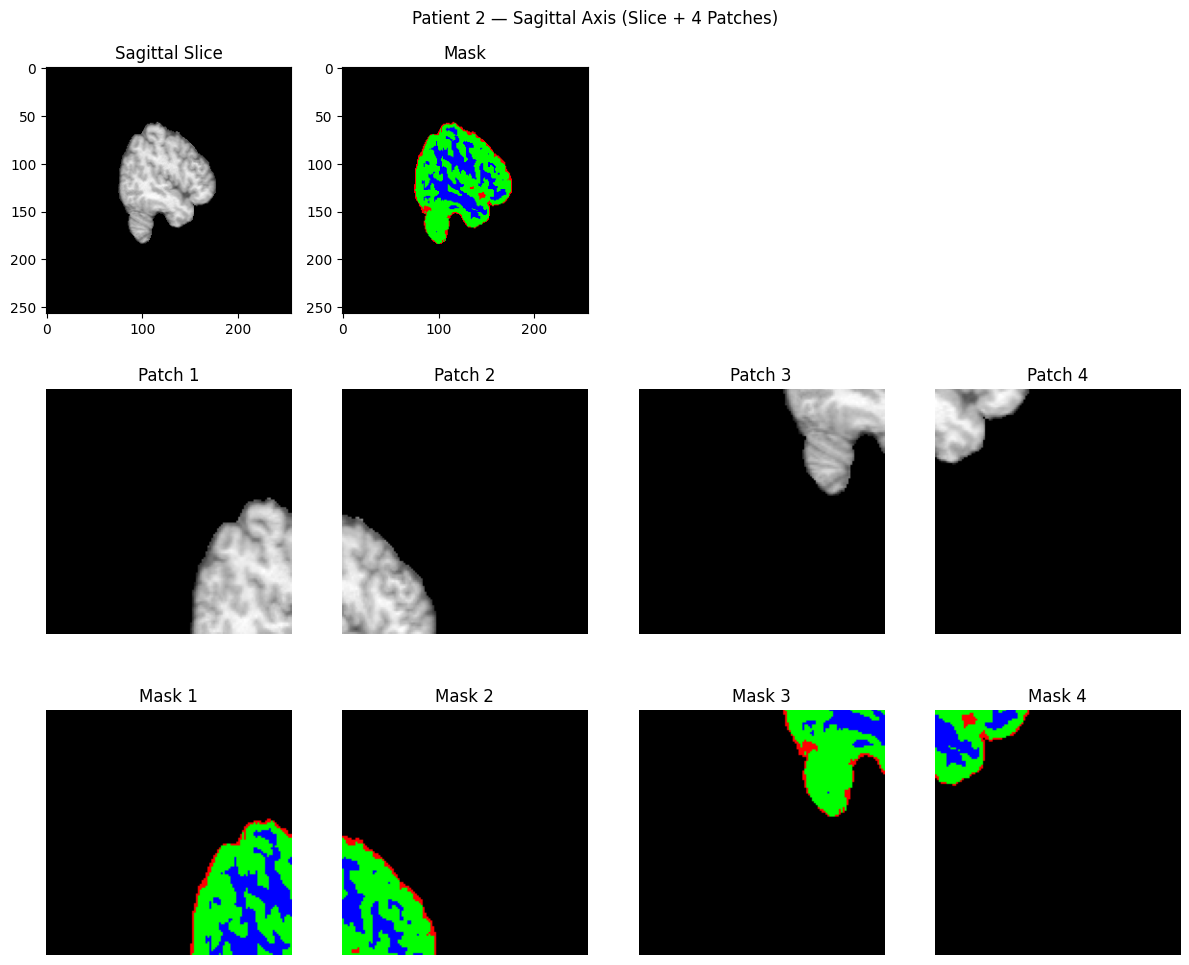

Coronal → slice 62/128 (range 32-96)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


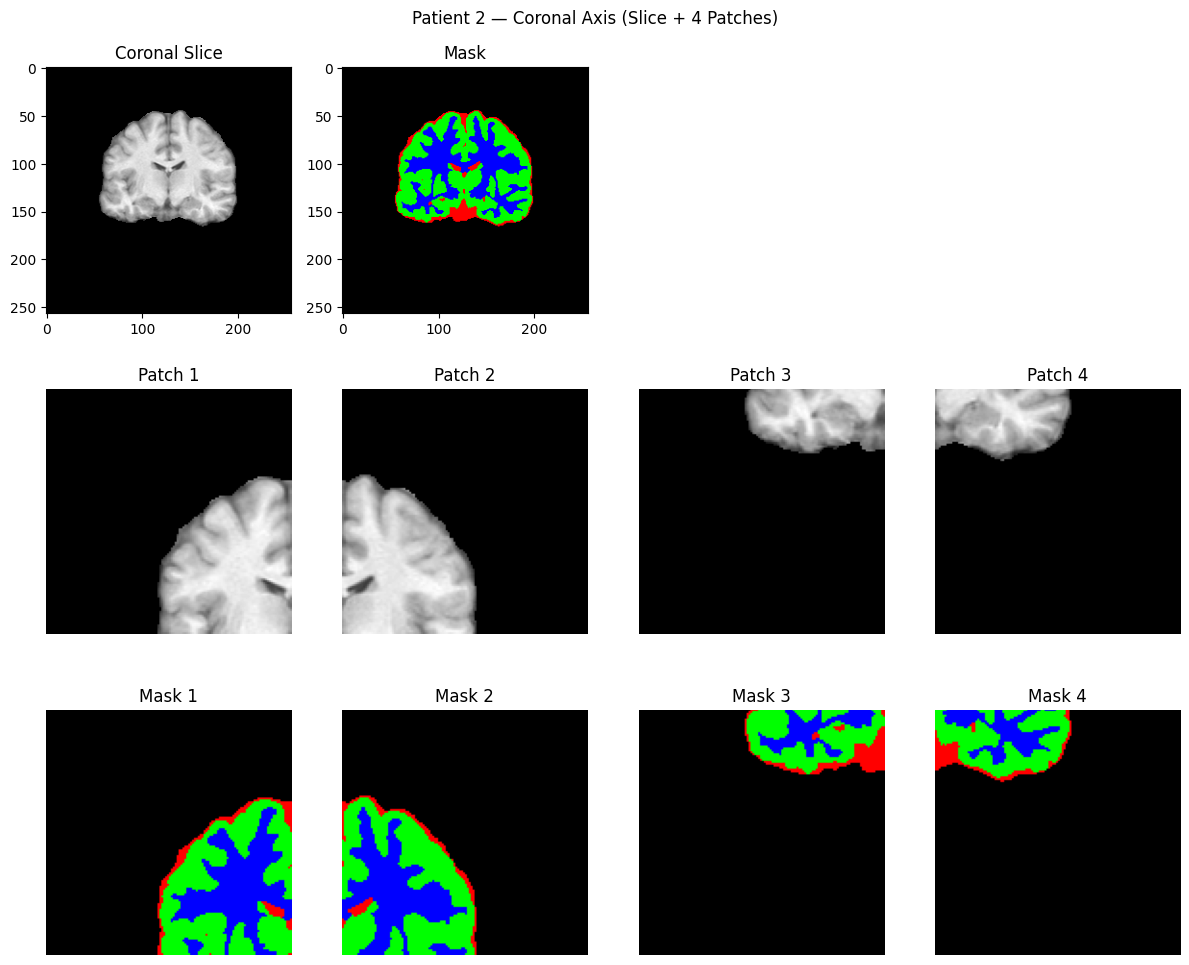

Axial → slice 71/256 (range 64-192)
Patch 1 shape: (128, 128)
Patch 2 shape: (128, 128)
Patch 3 shape: (128, 128)
Patch 4 shape: (128, 128)


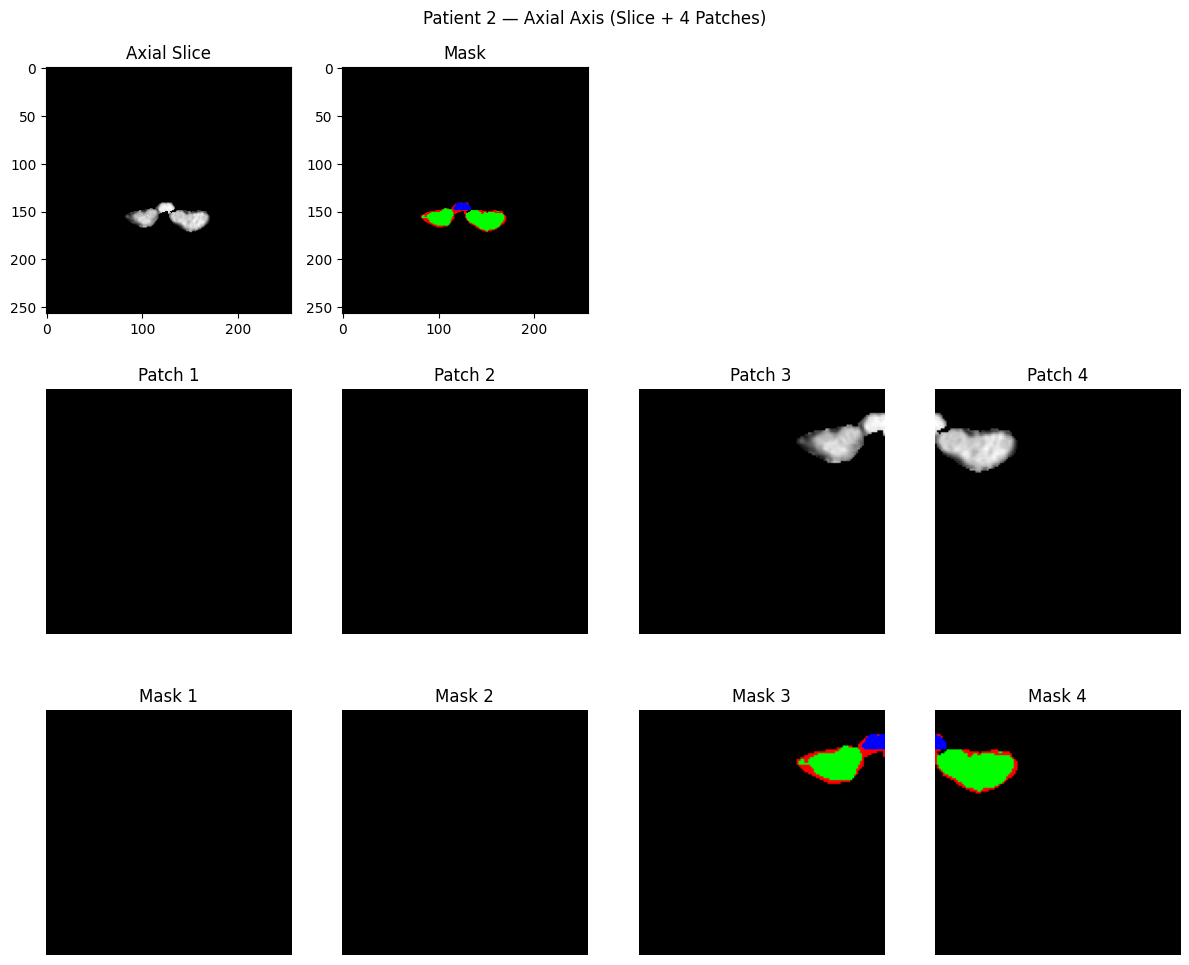

In [9]:
import os
import glob
import random
import warnings
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- CONFIG ---------------------- #
axes_names = ["Sagittal", "Coronal", "Axial"]

class_colors = {
    0: (0, 0, 0),   # background
    1: (1, 0, 0),   # red
    2: (0, 1, 0),   # green
    3: (0, 0, 1),   # blue
}

PATCH_SIZE = 128
NUM_PATIENTS = 3
TARGET_SLICE_SIZE = 256  # Ensure slice is at least 256x256


def extract_patches(img, mask, size=128):
    """Extract 4 fixed patches (128x128) from padded slice."""
    patches_img, patches_mask = [], []
    coords = [
        (0, 0),
        (0, size),
        (size, 0),
        (size, size)
    ]
    for x, y in coords:
        patches_img.append(img[x:x+size, y:y+size])
        patches_mask.append(mask[x:x+size, y:y+size])
    return patches_img, patches_mask

def pick_middle_slice(shape_len):
    """Pick random slice in middle half of axis."""
    low = shape_len // 4
    high = (3 * shape_len) // 4
    return random.randint(low, high), low, high

def colorize_mask(mask):
    """Convert class mask to RGB for visualization."""
    rgb = np.zeros(mask.shape + (3,), dtype=np.float32)
    for c, col in class_colors.items():
        rgb[mask == c] = col
    return rgb



if len(vols) == 0:
    raise RuntimeError("No volume/mask files found. Check your data directory.")

# Randomly pick patients
patient_indices = random.sample(range(len(vols)), NUM_PATIENTS)

for idx in patient_indices:
    print("\n===================================")
    print(f"   Patient {idx + 1}")
    print("===================================\n")

    vol = nib.load(vols[idx]).get_fdata()
    seg = nib.load(masks[idx]).get_fdata()



    for axis in range(3):
        slice_idx, low, high = pick_middle_slice(vol.shape[axis])
        print(f"{axes_names[axis]} → slice {slice_idx}/{vol.shape[axis]} (range {low}-{high})")

        # Get 2D slice
        vol_slice, seg_slice = get_slice_data(vol, seg, axis, slice_idx)

        # Pad slice to 256x256
        vol_slice, seg_slice = pad_slice(vol_slice, seg_slice, (TARGET_SLICE_SIZE,TARGET_SLICE_SIZE))

        # Extract 4 patches (128x128)
        img_patches, mask_patches = extract_patches(vol_slice, seg_slice, PATCH_SIZE)

        # Check shapes
        for i, patch in enumerate(img_patches):
            print(f"Patch {i+1} shape: {patch.shape}")

        # ---- plotting layout ---- #
        fig, axs = plt.subplots(3, 4, figsize=(12, 10))

        # Row 1: slice + mask
        axs[0, 0].imshow(vol_slice, cmap="gray"); axs[0, 0].set_title(f"{axes_names[axis]} Slice")
        axs[0, 1].imshow(colorize_mask(seg_slice)); axs[0, 1].set_title("Mask")
        axs[0, 2].axis("off"); axs[0, 3].axis("off")

        # Row 2 & 3: patches
        for i in range(4):
            axs[1, i].imshow(img_patches[i], cmap="gray")
            axs[1, i].set_title(f"Patch {i+1}")
            axs[1, i].axis("off")

            axs[2, i].imshow(colorize_mask(mask_patches[i]))
            axs[2, i].set_title(f"Mask {i+1}")
            axs[2, i].axis("off")

        plt.suptitle(f"Patient {idx+1} — {axes_names[axis]} Axis (Slice + 4 Patches)")
        plt.tight_layout()
        plt.show()


# 1-2

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.init import _calculate_fan_in_and_fan_out
from typing import Dict
import torch.nn.init as init


# -------------------------
# Helper modules
# -------------------------
class Conv1x1(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.layer = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        return self.layer(x)


class Conv1x1ReLU(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, padding=0),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.layer(x)


class Conv3x3ReLU(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.layer(x)


# -------------------------
# MNetStrict
# -------------------------
class MNetStrict(nn.Module):
    def __init__(self, in_channels=1, n_classes=4):
        super().__init__()

        self.up_mode = 'bilinear' 
        self.align_corners = False
        
        # Left leg (Pyramid)
        self.left1_1 = Conv1x1ReLU(in_channels, 64)
        self.left1_2 = Conv1x1ReLU(in_channels + 64, 64)

        self.left2_1 = Conv1x1ReLU(in_channels + 64, 128)
        self.left2_2 = Conv1x1ReLU(in_channels + 64 + 128, 128)

        self.left3_1 = Conv1x1ReLU(in_channels + 128, 256)
        self.left3_2 = Conv1x1ReLU(in_channels + 128 + 256, 256)

        self.left4_1 = Conv1x1ReLU(in_channels + 256, 512)
        self.left4_2 = Conv1x1ReLU(in_channels + 256 + 512, 512)
        self.left4_3 = Conv3x3ReLU(512, 512)

        self.left3_3 = Conv3x3ReLU(256 + 512, 256)
        self.left3_4 = Conv3x3ReLU( 512 + 256, 256)

        self.left2_3 = Conv3x3ReLU(256 + 128, 128)
        self.left2_4 = Conv3x3ReLU( 256 + 128, 128)

        self.left1_3 = Conv3x3ReLU(64 + 128, 64)
        self.left1_4 = Conv3x3ReLU( 64 + 128, 64)

        self.final = Conv1x1(512 + 256 + 128 + 64, n_classes)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        # Save original shape
        H, W = x.shape[2], x.shape[3]

        # Downsampling
        x1 = x
        x2 = self.pool(x1)
        x3 = self.pool(x2)
        x4 = self.pool(x3)

        # ----------------- Pyramid -----------------
        p1_1 = self.left1_1(x1)
        p1_2 = self.left1_2(torch.cat([x1, p1_1], dim=1))
        p1_out = self.pool(p1_2)

        p2_0 = torch.cat([x2, p1_out], dim=1)
        p2_1 = self.left2_1(p2_0)
        p2_2 = self.left2_2(torch.cat([p2_0, p2_1], dim=1))
        p2_out = self.pool(p2_2)

        p3_0 = torch.cat([x3, p2_out], dim=1)
        p3_1 = self.left3_1(p3_0)
        p3_2 = self.left3_2(torch.cat([p3_0, p3_1], dim=1))
        p3_out = self.pool(p3_2)

        p4_0 = torch.cat([x4, p3_out], dim=1)
        p4_1 = self.left4_1(p4_0)
        p4_2 = self.left4_2(torch.cat([p4_0, p4_1], dim=1))
        p4_3 = self.left4_3(p4_2)

        # ----------------- Upsampling -----------------
        p3_in = F.interpolate(p4_3, size=p3_2.shape[2:], mode=self.up_mode, align_corners=self.align_corners)
        p3_in2 = torch.cat([p3_2, p3_in], dim=1)
        p3_3 = self.left3_3(p3_in2)
        p3_4 = self.left3_4(torch.cat([p3_in, p3_3], dim=1))

        p2_in = F.interpolate(p3_4, size=p2_2.shape[2:], mode=self.up_mode,align_corners=self.align_corners)
        p2_in2 = torch.cat([p2_2, p2_in], dim=1)
        p2_3 = self.left2_3(p2_in2)
        p2_4 = self.left2_4(torch.cat([p2_in, p2_3], dim=1))

        p1_in = F.interpolate(p2_4, size=p1_2.shape[2:], mode=self.up_mode, align_corners=self.align_corners)
        p1_in2 = torch.cat([p1_2, p1_in], dim=1)
        p1_3 = self.left1_3(p1_in2)
        p1_4 = self.left1_4(torch.cat([p1_in, p1_3], dim=1))

        # ----------------- Final aggregation -----------------
        y3 = F.interpolate(p4_3, size=p3_4.shape[2:], mode=self.up_mode, align_corners=self.align_corners)
        y3_f = torch.cat([y3, p3_4], dim=1)

        y2 = F.interpolate(y3_f, size=p2_4.shape[2:], mode=self.up_mode, align_corners=self.align_corners)
        y2_f = torch.cat([y2, p2_4], dim=1)

        y1 = F.interpolate(y2_f, size=p1_4.shape[2:], mode=self.up_mode, align_corners=self.align_corners)
        y1_f = torch.cat([y1, p1_4], dim=1)

        y_final = self.final(y1_f)

        return {"pred": y_final}






In [11]:
model = MNetStrict(in_channels=1, n_classes=4)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable parameters:", trainable)
print("Non-trainable parameters:", non_trainable)


Trainable parameters: 7705476
Non-trainable parameters: 0


# 1-3

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

_eps = 1e-8

def compute_counts_per_class(pred: torch.Tensor, target: torch.Tensor, n_classes: int):
    """
    Compute TP, FP, FN per class for *one batch*.
    Returns three tensors of shape (n_classes,) with dtype=torch.float64.
    """
    # pred: logits or probabilities, shape (B, C, H, W) or (B, C, ...)
    # target: ground truth labels, shape (B, H, W, ...) integer class labels
    pred_labels = torch.argmax(pred, dim=1)  # shape (B, ...)
    pred_labels = pred_labels.view(-1)
    target = target.view(-1)

    tp = torch.zeros(n_classes, dtype=torch.float64)
    fp = torch.zeros(n_classes, dtype=torch.float64)
    fn = torch.zeros(n_classes, dtype=torch.float64)

    for cls in range(n_classes):
        pred_cls = (pred_labels == cls)
        target_cls = (target == cls)

        TP = (pred_cls & target_cls).sum(dtype=torch.float64)
        FP = (pred_cls & ~target_cls).sum(dtype=torch.float64)
        FN = (~pred_cls & target_cls).sum(dtype=torch.float64)

        tp[cls] = TP
        fp[cls] = FP
        fn[cls] = FN

    return tp, fp, fn


def compute_metrics_from_counts(tp, fp, fn, val_if_empty=0.0):
    """
    Compute precision, recall, iou, dice from aggregated counts.
    tp, fp, fn: 1D tensors (n_classes,) float
    Returns dict {cls: {...}} with Python floats.
    """
    n_classes = tp.shape[0]
    metrics = {}
    for cls in range(n_classes):
        TP = tp[cls].item()
        FP = fp[cls].item()
        FN = fn[cls].item()

        denom = TP + FP + FN
        if denom == 0:
            # class absent in both pred & gt for the whole evaluated set
            metrics[cls] = {
                "precision": float(val_if_empty),
                "recall": float(val_if_empty),
                "jaccard": float(val_if_empty),
                "dice": float(val_if_empty),
            }
            continue

        precision = TP / (TP + FP + _eps)
        recall = TP / (TP + FN + _eps)
        iou = TP / (TP + FP + FN + _eps)
        dice = (2 * TP) / (2 * TP + FP + FN + _eps)

        metrics[cls] = {
            "precision": float(precision),
            "recall": float(recall),
            "jaccard": float(iou),
            "dice": float(dice),
        }
    return metrics




## 1-3-2


In [13]:
# -------------------------
# Weight initialization
# -------------------------
def init_weights_lecun(module):
    """
    Compatible with model.apply(init_weights_lecun).
    Initializes Conv2d weights ~ N(0, std) with std = 1/sqrt(fan_in)
    and zeroes biases when present.
    """
    if isinstance(module, nn.Conv2d):
        fan_in, _ = _calculate_fan_in_and_fan_out(module.weight)
        std = (1.0 / fan_in) ** 0.5
        with torch.no_grad():
            module.weight.normal_(mean=0.0, std=std)
            if module.bias is not None:
                module.bias.zero_()


# 1-4

In [14]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, n_classes=4, num_epochs=10, lr=1e-4, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Class names
    class_names = {
        0: "Background",
        1: "CSF",
        2: "GM",
        3: "WM"
    }

    class_weights = torch.tensor([0.01, 1.2, 0.16, 0.3], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(class_weights)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.99)

    # ---- History storage for plotting ----
    history = {
        "train_loss": [],
        "val_loss": [],
        "dice": {cls: [] for cls in class_names}  # per class dice
    }

    for epoch in range(1, num_epochs + 1):

        # -------------------- TRAINING --------------------
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.long().to(device)

            optimizer.zero_grad()
            outputs = model(images)["pred"]
            loss = criterion(outputs, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        # ------------------ VALIDATION --------------------
        model.eval()
        val_loss = 0.0

        agg_tp = torch.zeros(n_classes, dtype=torch.float64)
        agg_fp = torch.zeros(n_classes, dtype=torch.float64)
        agg_fn = torch.zeros(n_classes, dtype=torch.float64)

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.long().to(device)

                outputs = model(images)["pred"]
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                tp, fp, fn = compute_counts_per_class(outputs.cpu(), masks.cpu(), n_classes)
                agg_tp += tp
                agg_fp += fp
                agg_fn += fn

        avg_val_loss = val_loss / len(val_loader)
        history["val_loss"].append(avg_val_loss)

        # Compute metrics from aggregated counts
        metrics = compute_metrics_from_counts(agg_tp, agg_fp, agg_fn, val_if_empty=0.0)

        # Store dice per class
        for cls in class_names:
            history["dice"][cls].append(metrics[cls]["dice"])

        # ----- Compute mean metrics across all classes -----
        mean_precision = sum(m["precision"] for m in metrics.values()) / n_classes
        mean_recall = sum(m["recall"] for m in metrics.values()) / n_classes
        mean_jaccard = sum(m["jaccard"] for m in metrics.values()) / n_classes   # renamed to Jaccard
        mean_dice = sum(m["dice"] for m in metrics.values()) / n_classes

        # -------------------- PRINT --------------------
        print(f"\nEpoch [{epoch}/{num_epochs}]")
        print(f" Train Loss: {avg_train_loss:.4f}")
        print(f" Val Loss:   {avg_val_loss:.4f}")
        print(f" Mean Precision: {mean_precision:.4f}")
        print(f" Mean Recall:    {mean_recall:.4f}")
        print(f" Mean Jaccard:   {mean_jaccard:.4f}")
        print(f" Mean Dice:      {mean_dice:.4f}")

        # Per-class summary
        for cls in range(n_classes):
            m = metrics[cls]
            print(f" {class_names[cls]} -> "
                  f"Precision: {m['precision']:.4f}, "
                  f"Recall: {m['recall']:.4f}, "
                  f"Jaccard: {m['jaccard']:.4f}, "
                  f"Dice: {m['dice']:.4f}")

    # -------------------- PLOTS --------------------
    epochs = range(1, num_epochs + 1)

    # Plot Dice for 3 important classes
    plt.figure(figsize=(8, 5))
    for cls in [1, 2, 3]:  # CSF, GM, WM
        plt.plot(epochs, history["dice"][cls], label=class_names[cls])
    plt.title("Dice Score per Class over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot train and val loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return 0



Epoch [1/10]
 Train Loss: 0.4688
 Val Loss:   0.2632
 Mean Precision: 0.7518
 Mean Recall:    0.8661
 Mean Jaccard:   0.6682
 Mean Dice:      0.7718
 Background -> Precision: 0.9999, Recall: 0.9896, Jaccard: 0.9894, Dice: 0.9947
 CSF -> Precision: 0.3018, Recall: 0.8903, Jaccard: 0.2910, Dice: 0.4508
 GM -> Precision: 0.8759, Recall: 0.7752, Jaccard: 0.6985, Dice: 0.8225
 WM -> Precision: 0.8295, Recall: 0.8094, Jaccard: 0.6940, Dice: 0.8194

Epoch [2/10]
 Train Loss: 0.3459
 Val Loss:   0.2456
 Mean Precision: 0.7645
 Mean Recall:    0.8752
 Mean Jaccard:   0.6850
 Mean Dice:      0.7901
 Background -> Precision: 0.9998, Recall: 0.9940, Jaccard: 0.9938, Dice: 0.9969
 CSF -> Precision: 0.3660, Recall: 0.8953, Jaccard: 0.3510, Dice: 0.5196
 GM -> Precision: 0.8985, Recall: 0.7499, Jaccard: 0.6913, Dice: 0.8175
 WM -> Precision: 0.7938, Recall: 0.8615, Jaccard: 0.7040, Dice: 0.8263

Epoch [3/10]
 Train Loss: 0.3229
 Val Loss:   0.2411
 Mean Precision: 0.7811
 Mean Recall:    0.8765
 Mea

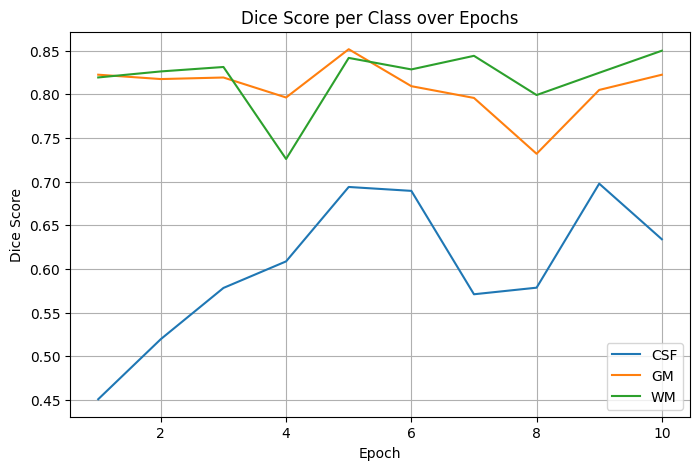

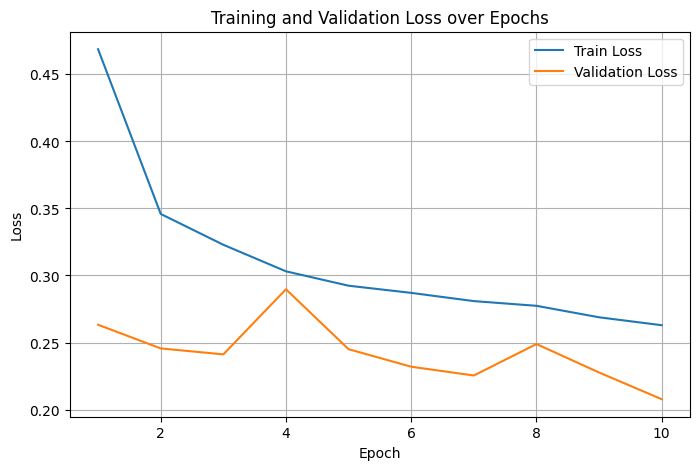

0

In [15]:

model.apply(init_weights_lecun)


# train_loader, val_loader should be defined
train_model(model, train_loader, val_loader, n_classes=4, num_epochs=10, lr=1e-4)

# 1-5


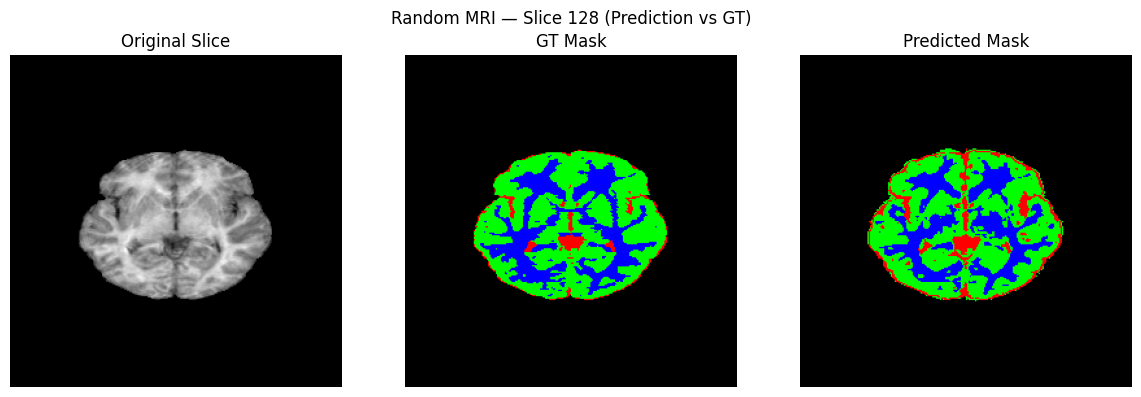

In [16]:
import random
import nibabel as nib
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------- CONFIG ---------------- #
PATCH_SIZE = 128
TARGET_SLICE_SIZE = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- HELPER ---------------- #
def predict_patches_and_reconstruct(img_patches, model, device='cpu'):
    """
    Run model on 4 patches and reconstruct the full slice.
    """
    reconstructed = np.zeros((PATCH_SIZE*2, PATCH_SIZE*2), dtype=np.int32)
    coords = [(0,0),(0,PATCH_SIZE),(PATCH_SIZE,0),(PATCH_SIZE,PATCH_SIZE)]
    model.to(device)
    model.eval()

    for i, (x, y) in enumerate(coords):
        patch = img_patches[i]
        x_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x_tensor)

            # Extract tensor from model dict output
            if isinstance(output, dict):
                if "pred" in output:
                    pred = output["pred"]
                else:
                    raise ValueError(f"Unknown dict keys in model output: {output.keys()}")
            else:
                pred = output

            pred_class = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

        reconstructed[x:x+PATCH_SIZE, y:y+PATCH_SIZE] = pred_class

    return reconstructed




# Pick a random MRI
idx = random.randint(0, len(vols)-1)
vol = nib.load(vols[idx]).get_fdata()
seg = nib.load(masks[idx]).get_fdata()

# Pick a random slice (axial)
slice_idx = vol.shape[2] // 2
vol_slice, seg_slice = get_slice_data(vol, seg, axis=2, slice_idx=slice_idx)

# Pad slice
vol_slice, seg_slice = pad_slice(vol_slice, seg_slice, (TARGET_SLICE_SIZE,TARGET_SLICE_SIZE))

# Extract 4 patches
img_patches, mask_patches = extract_patches(vol_slice, seg_slice, PATCH_SIZE)

# Predict on patches and reconstruct
predicted_slice = predict_patches_and_reconstruct(img_patches, model, device=device)

# ---------------- PLOTTING ---------------- #
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(vol_slice, cmap='gray')
plt.title("Original Slice")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(colorize_mask(seg_slice))
plt.title("GT Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(colorize_mask(predicted_slice))
plt.title("Predicted Mask")
plt.axis('off')

plt.suptitle(f"Random MRI — Slice {slice_idx} (Prediction vs GT)")
plt.tight_layout()
plt.show()
